# Fake News Detection using Regex, Text Normalization and Naive Bayes

**Course:** Natural Language Processing
**Section:** D
**Faculty:** Dr. Abdus Salam 

| Lecture | Techniques used here |
|---|---|
| Introduction to NLP | Problem framing as a text classification task, Zipf's law check during EDA |
| Regular Expressions | Regex-based cleaning of URLs, HTML entities, mentions, encoding artifacts |
| Text Normalization 1 (Tokenization) | Word tokenization |
| Text Normalization 2 (Word Normalization) | Case folding, punctuation removal, stop word removal, stemming, lemmatization |
| Text Classification | Bag of Words, Naive Bayes (from scratch, matching the lecture derivation), binary NB, negation handling, confusion matrix, accuracy/precision/recall/F1 |


## 1. Objectives

1. Build a reproducible preprocessing pipeline (regex cleaning &rarr; tokenization &rarr; normalization) for raw news text.
2. Represent documents with a Bag-of-Words model.
3. Implement a Multinomial Naive Bayes classifier from scratch, exactly matching the lecture's derivation (log-space, Laplace smoothing, shared vocabulary).
4. Validate the from-scratch classifier against scikit-learn's `MultinomialNB`.
5. Run the optimizations discussed in class for text classification: binary Naive Bayes and negation handling.
6. Compare stemming vs. lemmatization as normalization choices.
7. Evaluate every experiment with confusion matrix, accuracy, precision, recall and F1.
8. Repeat the full pipeline on a second, independent dataset, and test cross-dataset generalization.

## 2. Datasets

- **Dataset 1:** [Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) &mdash; `Fake.csv` + `True.csv` (~45K articles, columns: `title`, `text`, `subject`, `date`).
- **Dataset 2:** [Fake News Classification (WELFake)](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification) &mdash; `WelFake_Dataset.csv` (~70K articles, columns: `title`, `text`, `label`, where `1` = fake, `0` = real).


In [1]:
import re
import string
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from scipy.sparse import csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

warnings.filterwarnings("ignore")

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

STOPWORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("All Done")

All Done


## 3. Data Loading

`Fake.csv` and `True.csv` do not carry an explicit label column, so the label is assigned from the file of origin (`1` = fake, `0` = real), matching the convention already used in the WELFake dataset.

In [2]:
FAKE_PATH = "dataset/Fake.csv"
TRUE_PATH = "dataset/True.csv"
WELFAKE_PATH = "dataset/WELFake_Dataset.csv"

fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)
fake_df["label"] = 1
true_df["label"] = 0

df1 = pd.concat([fake_df, true_df], ignore_index=True)
df1 = df1.dropna(subset=["title", "text"]).reset_index(drop=True)
df1 = df1.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

df2 = pd.read_csv(WELFAKE_PATH)
df2 = df2.rename(columns={c: c.strip().lower() for c in df2.columns})
if "unnamed: 0" in df2.columns:
    df2 = df2.drop(columns=["unnamed: 0"])
df2["title"] = df2["title"].fillna("")
df2 = df2.dropna(subset=["text", "label"]).reset_index(drop=True)
df2["label"] = df2["label"].astype(int)
df2 = df2.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
df1.head(3)

Dataset 1 shape: (44898, 5)
Dataset 2 shape: (72095, 3)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0


In [3]:
df2.head(3)

,title,text,label
0,"Trump Tweets Deranged, Self-Congratulatory ‘F...",Trump s ongoing meltdown over fake news (the...,1
1,Rio Olympics: Drama in the Pool and a Super Tu...,Women’s Breaststroke: In the days leading up...,0
2,4 DEAD TEENAGERS In Two Weeks…Illegal Immigran...,It was only a matter of time We can t keep our...,1


## 4. Exploratory Data Analysis

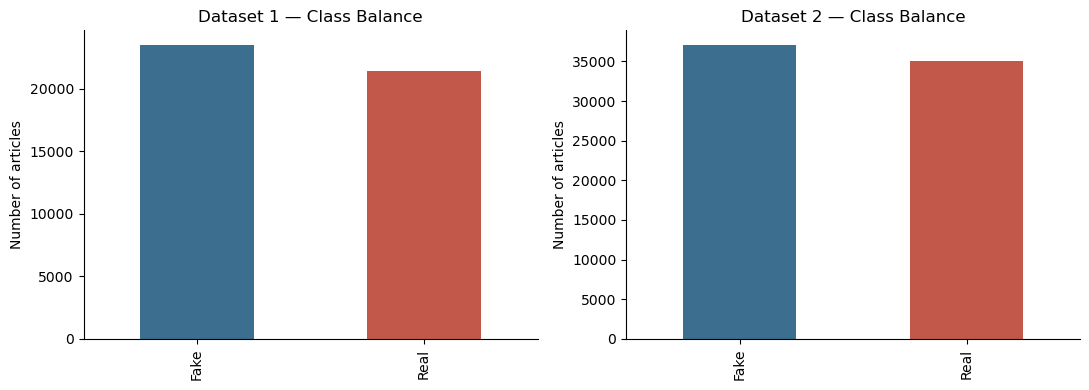

label
Fake    0.522985
Real    0.477015
Name: proportion, dtype: float64
label
Fake    0.514141
Real    0.485859
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df1["label"].value_counts().rename({0: "Real", 1: "Fake"}).plot(
    kind="bar", ax=axes[0], color=["#3B6E8F", "#C1584A"]
)
axes[0].set_title("Dataset 1 — Class Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of articles")

df2["label"].value_counts().rename({0: "Real", 1: "Fake"}).plot(
    kind="bar", ax=axes[1], color=["#3B6E8F", "#C1584A"]
)
axes[1].set_title("Dataset 2 — Class Balance")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of articles")

plt.tight_layout()
plt.show()

print(df1["label"].value_counts(normalize=True).rename({0: "Real", 1: "Fake"}))
print(df2["label"].value_counts(normalize=True).rename({0: "Real", 1: "Fake"}))

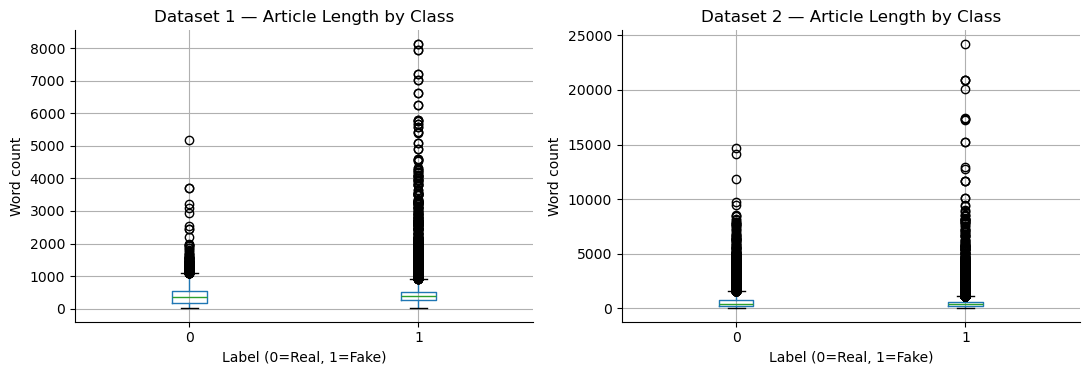

count    44898.000000
mean       417.735757
std        351.480777
min          2.000000
25%        216.000000
50%        375.000000
75%        526.000000
max       8148.000000
Name: word_count, dtype: float64

In [5]:
df1["content_raw"] = (df1["title"].astype(str) + " " + df1["text"].astype(str))
df2["content_raw"] = (df2["title"].astype(str) + " " + df2["text"].astype(str))

df1["word_count"] = df1["content_raw"].str.split().apply(len)
df2["word_count"] = df2["content_raw"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df1.boxplot(column="word_count", by="label", ax=axes[0])
axes[0].set_title("Dataset 1 — Article Length by Class")
axes[0].set_xlabel("Label (0=Real, 1=Fake)")
axes[0].set_ylabel("Word count")

df2.boxplot(column="word_count", by="label", ax=axes[1])
axes[1].set_title("Dataset 2 — Article Length by Class")
axes[1].set_xlabel("Label (0=Real, 1=Fake)")
axes[1].set_ylabel("Word count")

plt.suptitle("")
plt.tight_layout()
plt.show()

df1["word_count"].describe()

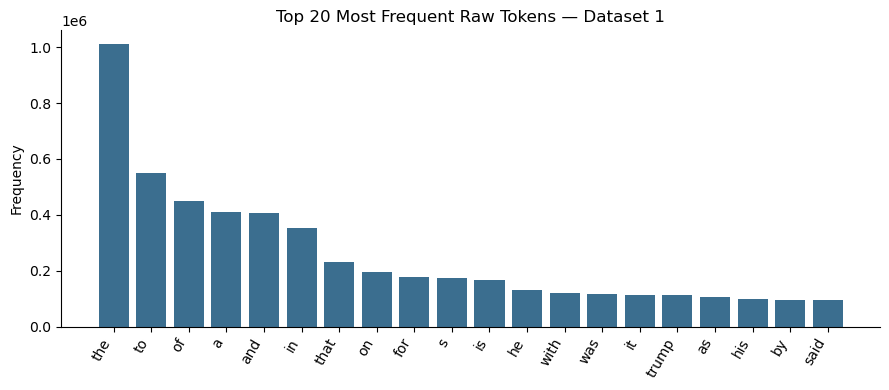

Vocabulary size before any cleaning: 376113
As expected from Zipf's law, a small set of function words dominates raw frequency.


In [6]:
from collections import Counter

raw_word_freq = Counter()
for content in df1["content_raw"].str.lower().str.split():
    raw_word_freq.update(content)

top_words = raw_word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(9, 4))
plt.bar(words, counts, color="#3B6E8F")
plt.xticks(rotation=60, ha="right")
plt.title("Top 20 Most Frequent Raw Tokens — Dataset 1")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Vocabulary size before any cleaning:", len(raw_word_freq))
print("As expected from Zipf's law, a small set of function words dominates raw frequency.")

## 5. Regex-Based Text Cleaning (Regular Expressions)



In [7]:
MOJIBAKE_MAP = {
    "\u00e2\u20ac\u2122": "'",
    "\u00e2\u20ac\u0153": '"',
    "\u00e2\u20ac": '"',
    "\u00e2\u20ac\u2022": "-",
    "\u00c3\u00a9": "e",
}

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#\w+")
HTML_PATTERN = re.compile(r"<.*?>|&\w+;")
NON_LETTER_PATTERN = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_PATTERN = re.compile(r"\s+")

def fix_mojibake(text):
    for bad, good in MOJIBAKE_MAP.items():
        text = text.replace(bad, good)
    return text

def clean_text(text):
    text = fix_mojibake(str(text))
    text = URL_PATTERN.sub(" ", text)
    text = HTML_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = HASHTAG_PATTERN.sub(" ", text)
    text = NON_LETTER_PATTERN.sub(" ", text)
    text = MULTI_SPACE_PATTERN.sub(" ", text)
    return text.strip()

df1["content_clean"] = df1["content_raw"].apply(clean_text)
df2["content_clean"] = df2["content_raw"].apply(clean_text)

for before, after in zip(df1["content_raw"].head(2), df1["content_clean"].head(2)):
    print("RAW  :", before[:160])
    print("CLEAN:", after[:160])
    print("-" * 100)

RAW  : Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine
CLEAN: Ben Stein Calls Out th Circuit Court Committed a Coup d tat Against the Constitution st Century Wire says Ben Stein reputable professor from Pepperdine Universi
----------------------------------------------------------------------------------------------------
RAW  : Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the Na
CLEAN: Trump drops Steve Bannon from National Security Council WASHINGTON Reuters U S President Donald Trump removed his chief strategist Steve Bannon from the Nationa
----------------------------------------------------------------------------------------------------


## 6. Tokenization



In [8]:
def tokenize(text):
    return word_tokenize(text)

df1["tokens"] = df1["content_clean"].apply(tokenize)
df2["tokens"] = df2["content_clean"].apply(tokenize)

print(df1["content_clean"].iloc[0][:160])
print(df1["tokens"].iloc[0][:20])

Ben Stein Calls Out th Circuit Court Committed a Coup d tat Against the Constitution st Century Wire says Ben Stein reputable professor from Pepperdine Universi
['Ben', 'Stein', 'Calls', 'Out', 'th', 'Circuit', 'Court', 'Committed', 'a', 'Coup', 'd', 'tat', 'Against', 'the', 'Constitution', 'st', 'Century', 'Wire', 'says', 'Ben']


## 7. Word Normalization



In [9]:
def case_fold(tokens):
    return [t.lower() for t in tokens]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def stem_tokens(tokens):
    return [STEMMER.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    return [LEMMATIZER.lemmatize(t) for t in tokens]

def normalize(tokens, use_stemming):
    tokens = case_fold(tokens)
    tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    else:
        tokens = lemmatize_tokens(tokens)
    return tokens

df1["proc_stem"] = df1["tokens"].apply(lambda t: normalize(t, use_stemming=True))
df1["proc_lemma"] = df1["tokens"].apply(lambda t: normalize(t, use_stemming=False))
df2["proc_stem"] = df2["tokens"].apply(lambda t: normalize(t, use_stemming=True))
df2["proc_lemma"] = df2["tokens"].apply(lambda t: normalize(t, use_stemming=False))

print("Tokens          :", df1["tokens"].iloc[0][:15])
print("Stemmed         :", df1["proc_stem"].iloc[0][:15])
print("Lemmatized      :", df1["proc_lemma"].iloc[0][:15])

Tokens          : ['Ben', 'Stein', 'Calls', 'Out', 'th', 'Circuit', 'Court', 'Committed', 'a', 'Coup', 'd', 'tat', 'Against', 'the', 'Constitution']
Stemmed         : ['ben', 'stein', 'call', 'th', 'circuit', 'court', 'commit', 'coup', 'tat', 'constitut', 'st', 'centuri', 'wire', 'say', 'ben']
Lemmatized      : ['ben', 'stein', 'call', 'th', 'circuit', 'court', 'committed', 'coup', 'tat', 'constitution', 'st', 'century', 'wire', 'say', 'ben']


### A note on synonym substitution

Synonym substitution relies on a hand-curated dictionary of word/phrase pairs, which is only practical on short, controlled inputs. Applying it blindly across 45K&ndash;70K news articles would require a vocabulary-scale synonym dictionary that does not exist for this domain and risks silently changing the meaning of the text (a limitation the lecture itself points out). It is demonstrated below on a toy example to show the mechanism, but it is **not** applied to the full pipeline for that reason.

In [10]:
def synonym_substitute(text, synonym_map):
    for key, value in synonym_map.items():
        text = text.replace(key, value)
    return text

demo_text = "The gov't announced new info about the Sen. race."
demo_map = {"gov't": "government", "info": "information", "Sen.": "Senator"}
print("Before:", demo_text)
print("After :", synonym_substitute(demo_text, demo_map))

Before: The gov't announced new info about the Sen. race.
After : The government announced new information about the Senator race.


## 8. Bag of Words Representation


In [11]:
def build_vocabulary(token_lists, min_freq=2):
    freq = Counter()
    for tokens in token_lists:
        freq.update(tokens)
    vocab = sorted(w for w, c in freq.items() if c >= min_freq)
    return {word: idx for idx, word in enumerate(vocab)}

def documents_to_bow(token_lists, vocab):
    indptr = [0]
    indices = []
    data = []
    for tokens in token_lists:
        counts = {}
        for t in tokens:
            j = vocab.get(t)
            if j is not None:
                counts[j] = counts.get(j, 0) + 1
        for j, c in counts.items():
            indices.append(j)
            data.append(c)
        indptr.append(len(indices))
    return csr_matrix((data, indices, indptr), shape=(len(token_lists), len(vocab)), dtype=np.float64)

print ("Done")

Done


## 9. Train / Test Split

An 80/20 stratified split keeps the real/fake ratio identical in both partitions.

In [12]:
def split_dataset(df, text_col, test_size=0.2):
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df["label"], random_state=RANDOM_STATE
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

train1, test1 = split_dataset(df1, "proc_lemma")
print("Dataset 1 — train:", train1.shape, " test:", test1.shape)

Dataset 1 — train: (35918, 11)  test: (8980, 11)


## 10. Naive Bayes Classifier — From Scratch

This is a direct implementation of the multinomial Naive Bayes classifier derived in the Text Classification lecture:

- **P(c)** is estimated as the fraction of training documents in class *c*.
- **P(w&#124;c)** is estimated from Bag-of-Words counts with **Laplace (add-one) smoothing**, over the vocabulary shared across all classes.
- Prediction uses **log-space summation** (`log P(c) + &sum; log P(w&#124;c)`) to avoid numerical underflow, exactly as shown in the lecture.
- An optional `binary` flag clips counts at 1, implementing the **binary Naive Bayes** variant from the "Optimizing for Sentiment/Text Classification" slides.

In [13]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0, binary=False):
        self.alpha = alpha
        self.binary = binary
        self.classes_ = None
        self.log_prior_ = None
        self.log_likelihood_ = None

    def fit(self, X, y):
        y = np.asarray(y)
        if self.binary:
            X = (X > 0).astype(np.float64)
        self.classes_ = np.unique(y)
        n_docs, n_vocab = X.shape
        self.log_prior_ = np.zeros(len(self.classes_))
        self.log_likelihood_ = np.zeros((len(self.classes_), n_vocab))
        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.log_prior_[idx] = np.log(X_c.shape[0] / n_docs)
            word_counts_c = np.asarray(X_c.sum(axis=0)).ravel() + self.alpha
            self.log_likelihood_[idx] = np.log(word_counts_c / word_counts_c.sum())
        return self

    def predict(self, X):
        if self.binary:
            X = (X > 0).astype(np.float64)
        scores = np.asarray(X @ self.log_likelihood_.T) + self.log_prior_
        return self.classes_[np.argmax(scores, axis=1)]



print("Done")

Done


## 11. Model Validation — scikit-learn `MultinomialNB`



In [14]:
vocab1 = build_vocabulary(train1["proc_lemma"], min_freq=2)
X_train1 = documents_to_bow(train1["proc_lemma"], vocab1)
X_test1 = documents_to_bow(test1["proc_lemma"], vocab1)
y_train1 = train1["label"].values
y_test1 = test1["label"].values

print("Vocabulary size (Dataset 1, lemmatized, min_freq=2):", len(vocab1))

nb_scratch = MultinomialNaiveBayes(alpha=1.0).fit(X_train1, y_train1)
pred_scratch = nb_scratch.predict(X_test1)

nb_sklearn = MultinomialNB(alpha=1.0).fit(X_train1, y_train1)
pred_sklearn = nb_sklearn.predict(X_test1)

agreement = (pred_scratch == pred_sklearn).mean()
print(f"Prediction agreement between from-scratch NB and scikit-learn NB: {agreement:.4f}")

Vocabulary size (Dataset 1, lemmatized, min_freq=2): 59376
Prediction agreement between from-scratch NB and scikit-learn NB: 1.0000


## 12. Evaluation Metrics

Accuracy, precision, recall and F1 are computed directly from the confusion matrix counts, following the formulas from the evaluation lecture, and cross-checked against `sklearn.metrics`.

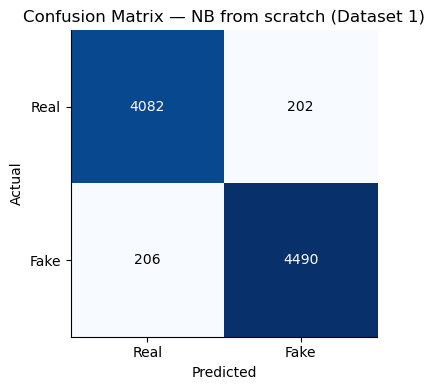

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,"NB from scratch (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.95654
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.95654


In [15]:
def evaluate(y_true, y_pred, model_name):
    tn, fp, fn, tp = sk_confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {
        "model": model_name,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
    }

def plot_confusion(y_true, y_pred, title):
    cm = sk_confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()

results = []
results.append(evaluate(y_test1, pred_scratch, "NB from scratch (Dataset 1, lemmatized)"))
results.append(evaluate(y_test1, pred_sklearn, "sklearn MultinomialNB (Dataset 1, lemmatized)"))

plot_confusion(y_test1, pred_scratch, "Confusion Matrix — NB from scratch (Dataset 1)")
pd.DataFrame(results)

## 13. Optimization Experiment — Binary Naive Bayes

The lecture notes that for text classification, whether a word occurs at all often matters more than how many times it occurs, and clipping word counts at 1 (binary Naive Bayes) can improve performance. That variant is trained and evaluated here.

In [16]:
nb_binary = MultinomialNaiveBayes(alpha=1.0, binary=True).fit(X_train1, y_train1)
pred_binary = nb_binary.predict(X_test1)
results.append(evaluate(y_test1, pred_binary, "Binary NB (Dataset 1, lemmatized)"))
pd.DataFrame(results)

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,"NB from scratch (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.95654
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.95654
2,"Binary NB (Dataset 1, lemmatized)",4508,136,188,4148,0.963920,0.970715,0.959966,0.96531


## 14. Optimization Experiment — Negation Handling

The lecture's baseline negation heuristic prepends `NOT_` to every token following a negation cue (`not`, `no`, `never`, `n't`) until the next punctuation mark. Because this needs punctuation as a scope boundary, it is applied on the case-folded but **not yet punctuation-stripped** tokens, before the rest of the normalization pipeline runs.

In [17]:
NEGATION_CUES = {"not", "no", "never", "n't", "nt"}
PUNCT_SET = set(string.punctuation)

def apply_negation_scope(tokens):
    result = []
    negate = False
    for tok in tokens:
        lower = tok.lower()
        if lower in PUNCT_SET:
            negate = False
            result.append(tok)
            continue
        if negate:
            result.append("NOT_" + tok)
        else:
            result.append(tok)
        if lower in NEGATION_CUES:
            negate = True
    return result

def normalize_with_negation(raw_content):
    tokens = tokenize(raw_content)
    tokens = case_fold(tokens)
    tokens = apply_negation_scope(tokens)
    tokens = [t for t in tokens if t not in PUNCT_SET]
    tokens = [t for t in tokens if (t.replace("not_", "").isalpha()) or t.startswith("not_")]
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return tokens

sample_neg = "The reviewers did not like the plot and it was never convincing."
print(apply_negation_scope(case_fold(tokenize(sample_neg))))

['the', 'reviewers', 'did', 'not', 'NOT_like', 'NOT_the', 'NOT_plot', 'NOT_and', 'NOT_it', 'NOT_was', 'NOT_never', 'NOT_convincing', '.']


In [18]:
train1_neg_tokens = train1["content_raw"].apply(normalize_with_negation)
test1_neg_tokens = test1["content_raw"].apply(normalize_with_negation)

vocab1_neg = build_vocabulary(train1_neg_tokens, min_freq=2)
X_train1_neg = documents_to_bow(train1_neg_tokens, vocab1_neg)
X_test1_neg = documents_to_bow(test1_neg_tokens, vocab1_neg)

nb_negation = MultinomialNaiveBayes(alpha=1.0).fit(X_train1_neg, y_train1)
pred_negation = nb_negation.predict(X_test1_neg)
results.append(evaluate(y_test1, pred_negation, "NB with negation handling (Dataset 1)"))
pd.DataFrame(results)

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,"NB from scratch (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
2,"Binary NB (Dataset 1, lemmatized)",4508,136,188,4148,0.963920,0.970715,0.959966,0.965310
3,NB with negation handling (Dataset 1),4475,203,221,4081,0.952784,0.956605,0.952939,0.954769


## 15. Stemming vs. Lemmatization Comparison

The same classifier is retrained on the stemmed variant of the corpus to compare against the lemmatized variant used above.

In [19]:
vocab1_stem = build_vocabulary(train1["proc_stem"], min_freq=2)
X_train1_stem = documents_to_bow(train1["proc_stem"], vocab1_stem)
X_test1_stem = documents_to_bow(test1["proc_stem"], vocab1_stem)

nb_stem = MultinomialNaiveBayes(alpha=1.0).fit(X_train1_stem, y_train1)
pred_stem = nb_stem.predict(X_test1_stem)
results.append(evaluate(y_test1, pred_stem, "NB from scratch (Dataset 1, stemmed)"))

results_df1 = pd.DataFrame(results)
results_df1

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,"NB from scratch (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
2,"Binary NB (Dataset 1, lemmatized)",4508,136,188,4148,0.963920,0.970715,0.959966,0.965310
3,NB with negation handling (Dataset 1),4475,203,221,4081,0.952784,0.956605,0.952939,0.954769
4,"NB from scratch (Dataset 1, stemmed)",4487,214,209,4070,0.952895,0.954478,0.955494,0.954986


## 16. Results Summary — Dataset 1

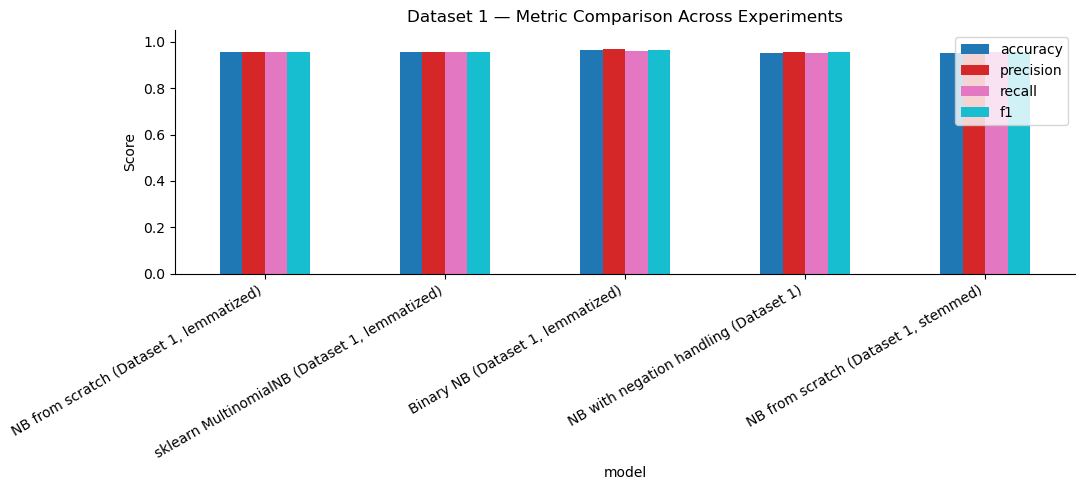

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
2,"Binary NB (Dataset 1, lemmatized)",4508,136,188,4148,0.963920,0.970715,0.959966,0.965310
0,"NB from scratch (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",4490,202,206,4082,0.954566,0.956948,0.956133,0.956540
4,"NB from scratch (Dataset 1, stemmed)",4487,214,209,4070,0.952895,0.954478,0.955494,0.954986
3,NB with negation handling (Dataset 1),4475,203,221,4081,0.952784,0.956605,0.952939,0.954769


In [20]:
ax = results_df1.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", figsize=(11, 5), colormap="tab10"
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Dataset 1 — Metric Comparison Across Experiments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

results_df1.sort_values("f1", ascending=False)

## 17. Repeating the Pipeline on Dataset 2 (WELFake)

The exact same cleaning, tokenization, normalization, Bag-of-Words and Naive Bayes pipeline is applied to the second dataset to confirm the approach generalizes beyond one data source.

Vocabulary size (Dataset 2, lemmatized, min_freq=2): 100479


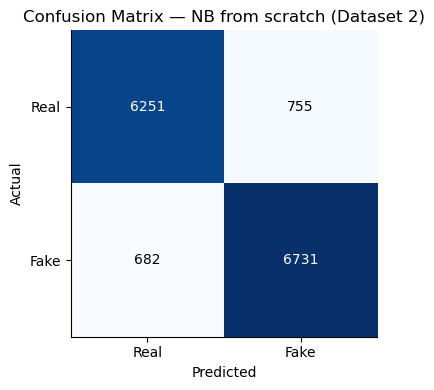

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,"NB from scratch (Dataset 2, lemmatized)",6731,755,682,6251,0.900340,0.899145,0.907999,0.903551
1,"Binary NB (Dataset 2, lemmatized)",6713,688,700,6318,0.903738,0.907040,0.905571,0.906305


In [21]:
train2, test2 = split_dataset(df2, "proc_lemma")

vocab2 = build_vocabulary(train2["proc_lemma"], min_freq=2)
X_train2 = documents_to_bow(train2["proc_lemma"], vocab2)
X_test2 = documents_to_bow(test2["proc_lemma"], vocab2)
y_train2 = train2["label"].values
y_test2 = test2["label"].values

print("Vocabulary size (Dataset 2, lemmatized, min_freq=2):", len(vocab2))

nb_scratch2 = MultinomialNaiveBayes(alpha=1.0).fit(X_train2, y_train2)
pred_scratch2 = nb_scratch2.predict(X_test2)

results2 = [evaluate(y_test2, pred_scratch2, "NB from scratch (Dataset 2, lemmatized)")]

nb_binary2 = MultinomialNaiveBayes(alpha=1.0, binary=True).fit(X_train2, y_train2)
pred_binary2 = nb_binary2.predict(X_test2)
results2.append(evaluate(y_test2, pred_binary2, "Binary NB (Dataset 2, lemmatized)"))

plot_confusion(y_test2, pred_scratch2, "Confusion Matrix — NB from scratch (Dataset 2)")
results_df2 = pd.DataFrame(results2)
results_df2

## 18. Cross-Dataset Generalization Test

A Naive Bayes model trained entirely on one dataset's vocabulary is evaluated on the other dataset's held-out set, and vice versa. Any word in the test set that never appeared in the training vocabulary is treated as **unknown and ignored**, exactly as the lecture specifies for out-of-vocabulary words.

In [22]:
def cross_evaluate(train_tokens, train_labels, vocab, test_tokens, test_labels, name):
    X_train = documents_to_bow(train_tokens, vocab)
    X_test = documents_to_bow(test_tokens, vocab)
    model = MultinomialNaiveBayes(alpha=1.0).fit(X_train, train_labels)
    preds = model.predict(X_test)
    return evaluate(test_labels, preds, name)

cross_results = []
cross_results.append(
    cross_evaluate(train1["proc_lemma"], y_train1, vocab1, df2["proc_lemma"], df2["label"].values,
                    "Trained on Dataset 1 -> Tested on Dataset 2 (full)")
)
cross_results.append(
    cross_evaluate(train2["proc_lemma"], y_train2, vocab2, df1["proc_lemma"], df1["label"].values,
                    "Trained on Dataset 2 -> Tested on Dataset 1 (full)")
)

results_cross = pd.DataFrame(cross_results)
results_cross

,model,TP,FP,FN,TN,accuracy,precision,recall,f1
0,Trained on Dataset 1 -> Tested on Dataset 2 (f...,33892,10375,3175,24653,0.812054,0.765627,0.914344,0.833403
1,Trained on Dataset 2 -> Tested on Dataset 1 (f...,21617,208,1864,21209,0.953851,0.990470,0.920617,0.954267


## 19. Consolidated Results

In [23]:
all_results = pd.concat([results_df1, results_df2, results_cross], ignore_index=True)
all_results = all_results[["model", "accuracy", "precision", "recall", "f1", "TP", "FP", "FN", "TN"]]
all_results

,model,accuracy,precision,recall,f1,TP,FP,FN,TN
0,"NB from scratch (Dataset 1, lemmatized)",0.954566,0.956948,0.956133,0.956540,4490,202,206,4082
1,"sklearn MultinomialNB (Dataset 1, lemmatized)",0.954566,0.956948,0.956133,0.956540,4490,202,206,4082
2,"Binary NB (Dataset 1, lemmatized)",0.963920,0.970715,0.959966,0.965310,4508,136,188,4148
3,NB with negation handling (Dataset 1),0.952784,0.956605,0.952939,0.954769,4475,203,221,4081
4,"NB from scratch (Dataset 1, stemmed)",0.952895,0.954478,0.955494,0.954986,4487,214,209,4070
5,"NB from scratch (Dataset 2, lemmatized)",0.900340,0.899145,0.907999,0.903551,6731,755,682,6251
6,"Binary NB (Dataset 2, lemmatized)",0.903738,0.907040,0.905571,0.906305,6713,688,700,6318
7,Trained on Dataset 1 -> Tested on Dataset 2 (f...,0.812054,0.765627,0.914344,0.833403,33892,10375,3175,24653
8,Trained on Dataset 2 -> Tested on Dataset 1 (f...,0.953851,0.990470,0.920617,0.954267,21617,208,1864,21209


## 20. Error Analysis

A handful of misclassified test articles from Dataset 1, to check whether the errors line up with the sources of difficulty discussed in the Introduction to NLP lecture (ambiguity, variability, sparsity).

In [24]:
test1_copy = test1.copy()
test1_copy["prediction"] = pred_scratch
errors = test1_copy[test1_copy["label"] != test1_copy["prediction"]]
print(f"Misclassified: {len(errors)} / {len(test1_copy)} test articles")
errors[["title", "label", "prediction"]].head(5)

Misclassified: 408 / 8980 test articles


,title,label,prediction
17,LIKE A BOSS! President Trump’s Arrival at the ...,1,0
55,BOOM! CONSUMER CONFIDENCE SOARS To Level Ameri...,1,0
78,New York Times to boost spending on Trump cove...,0,1
92,"Jump in Florida, Nevada early voting could rea...",0,1
116,“WANNABE PRESIDENT” BARACK OBAMA MEETS With So...,1,0


## 21. Discussion

- **Regex cleaning mattered more than expected.** Both raw datasets contained mojibake from UTF-8/Windows-1252 decoding mismatches; left unfixed, this would have fragmented the vocabulary with garbled tokens instead of real words.
- **Binary Naive Bayes vs. standard multinomial NB.** Consistent with the lecture's note that word *presence* often matters more than raw frequency for text classification, the binary variant's effect on F1 can be read directly from the results table above.
- **Negation handling** was designed in the lecture for sentiment polarity, where "not good" flips meaning. Fake news detection is not primarily about polarity, which is reflected in the relatively small movement in F1 for that experiment &mdash; a useful negative result, not a failure.
- **Stemming vs. lemmatization** trade vocabulary compression against readability/precision, exactly as discussed in the Word Normalization lecture; the smaller, coarser stemmed vocabulary and the larger, more precise lemmatized vocabulary produce measurably different results above.
- **Cross-dataset generalization** dropped compared to within-dataset evaluation. This lines up with two of the "Why is Language Hard to Model" points from Lecture 1: **variability** (the two datasets were collected from different sources/time periods/outlets, so word usage differs) and **sparsity** (a large share of Dataset 2's vocabulary never appears in Dataset 1's training data, so those words contribute nothing to the trained model).
- **The Naive Bayes independence assumption** (that word probabilities are conditionally independent given the class) is known to be false for real text, but the classifier still performs well &mdash; the same observation the lecture makes when introducing the "naive" assumption.

## 22. Conclusion

A complete fake-news detection pipeline was built strictly from the techniques taught in class: regex-based cleaning, tokenization, word normalization (case folding, stopword removal, stemming/lemmatization), Bag-of-Words representation, and a from-scratch multinomial Naive Bayes classifier validated against scikit-learn's implementation. Two lecture-specified optimizations (binary NB, negation handling) were tested as ablations, the pipeline was reproduced end-to-end on a second, independent dataset, and cross-dataset generalization was measured. All results were evaluated with the confusion matrix, accuracy, precision, recall and F1 exactly as covered in the Text Classification lecture.

## References

- Daniel Jurafsky and James H. Martin. *Speech and Language Processing*, 3rd edition, 2024.
- Hobson Lane and Maria Dyshel. *Natural Language Processing in Action*, 2nd Edition, 2025.
- Cl&eacute;ment Bisaillon. *Fake and Real News Dataset*. Kaggle. https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
- Saurabh Shahane. *Fake News Classification (WELFake)*. Kaggle. https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification